# TV4 - Company Sentiment Insights & WordCloud

Notebook phân tích 8.417 review của 180 công ty. Năm case study được chọn theo số review lớn nhất; kết quả chỉ mang tính mô tả, không phải xếp hạng doanh nghiệp.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from scripts.run_company_insights import run
manifest = run(top_n=5)
print(f"Nguồn: {manifest['source_rows']:,} reviews / {manifest['company_count']} công ty")
print('Case study:', ', '.join(item['company'] for item in manifest['selected_companies']))

Nguồn: 8,417 reviews / 180 công ty
Case study: FPT Software, NashTech, Bosch Global Software Technologies Company Limited, VNG Corporation, KMS Technology


## 1. Phân bố cảm xúc của 5 công ty có nhiều review nhất

In [2]:
distribution = pd.read_csv(PROJECT_ROOT / 'reports/company_insights/company_sentiment_distribution.csv')
sentiment_table = distribution.pivot(index='Company Name', columns='sentiment', values='percentage').fillna(0)
sentiment_table = sentiment_table.reindex(columns=['Negative', 'Neutral', 'Positive'], fill_value=0).round(2)
sentiment_table

sentiment,Negative,Neutral,Positive
Company Name,,,
Bosch Global Software Technologies Company Limited,15.47,44.96,39.57
FPT Software,8.89,33.37,57.75
KMS Technology,4.78,14.74,80.48
NashTech,4.55,26.30,69.16
VNG Corporation,2.70,21.62,75.68


## 2. Điểm khía cạnh và khuyến nghị HR

In [3]:
aspects = pd.read_csv(PROJECT_ROOT / 'reports/company_insights/company_aspect_summary.csv')
aspects

,Company Name,Salary & benefits,Training & learning,Management cares about me,Culture & fun,Office & workspace,review_count,recommendation
0,Bosch Global Software Technologies Company Lim...,3.108,3.173,3.176,3.511,3.881,278,"Rà soát lương, thưởng và phúc lợi theo benchma..."
1,FPT Software,3.174,3.904,3.553,3.964,4.021,2014,"Rà soát lương, thưởng và phúc lợi theo benchma..."
2,KMS Technology,3.618,3.912,3.968,4.159,4.120,251,"Rà soát lương, thưởng và phúc lợi theo benchma..."
3,NashTech,3.458,3.964,3.646,3.841,3.786,308,"Rà soát lương, thưởng và phúc lợi theo benchma..."
4,VNG Corporation,3.668,3.629,3.625,3.938,4.351,259,"Cải thiện 1:1, phản hồi hai chiều và năng lực ..."


## 3. WordCloud tích cực và tiêu cực toàn bộ dữ liệu

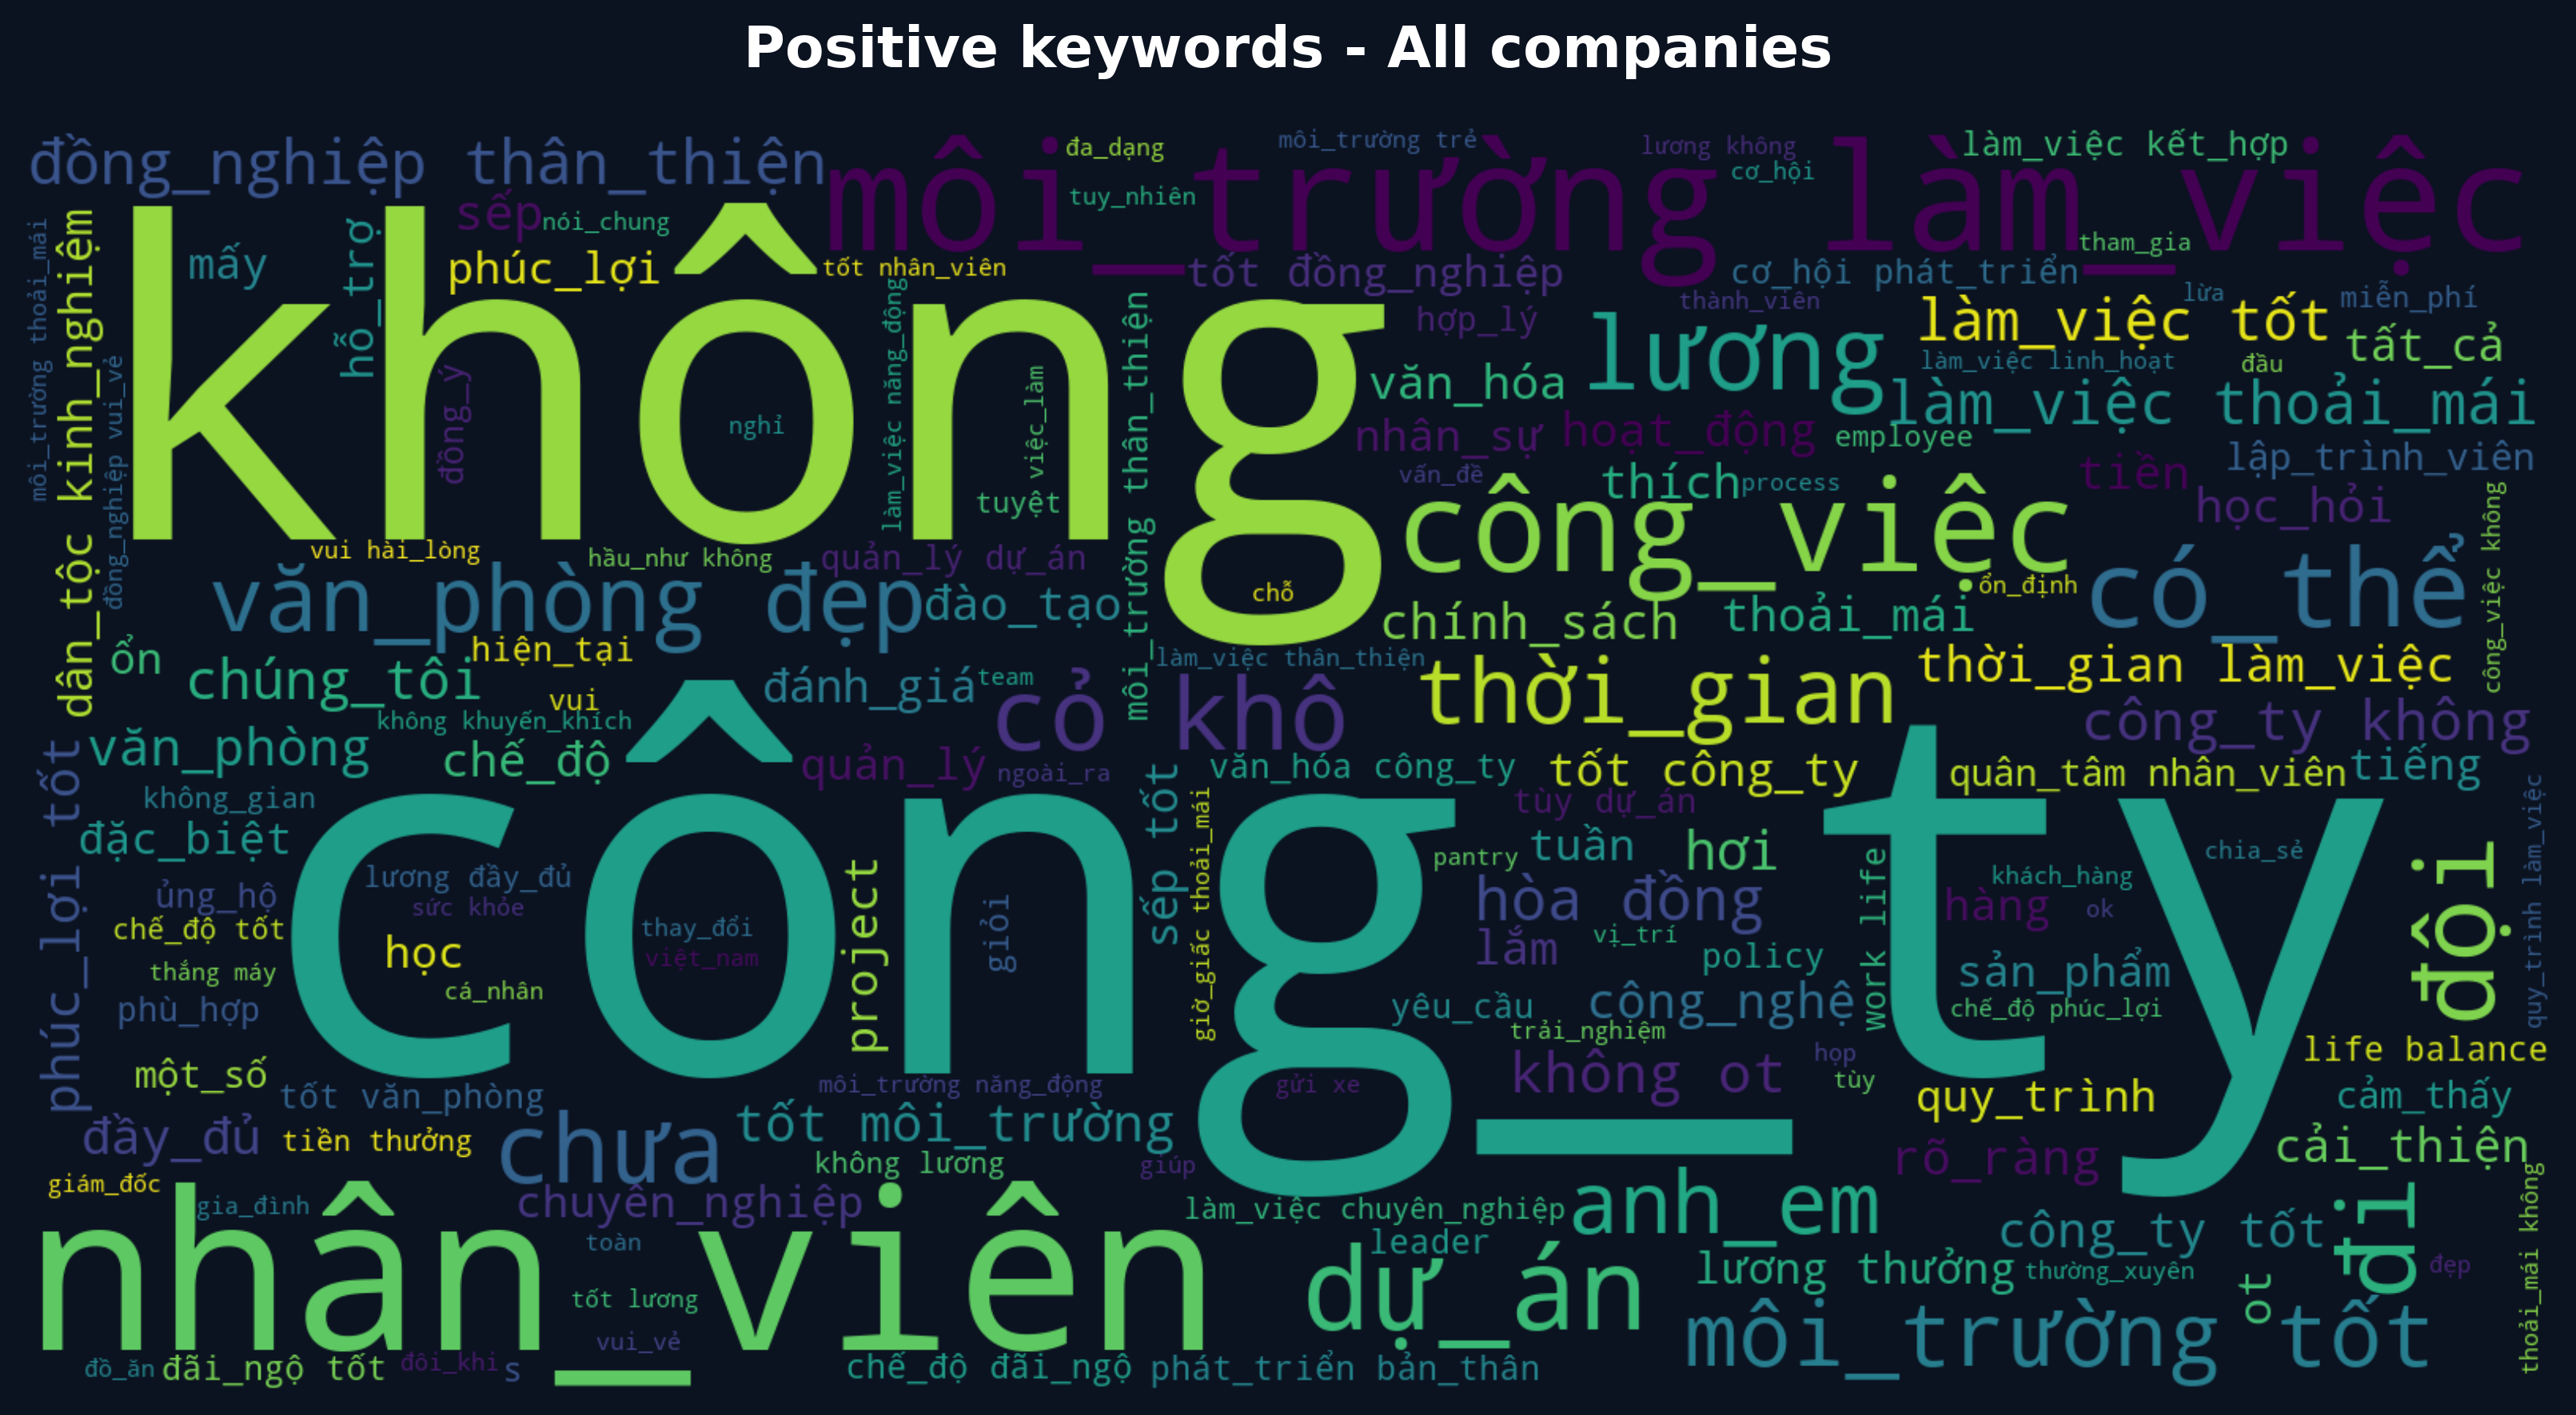

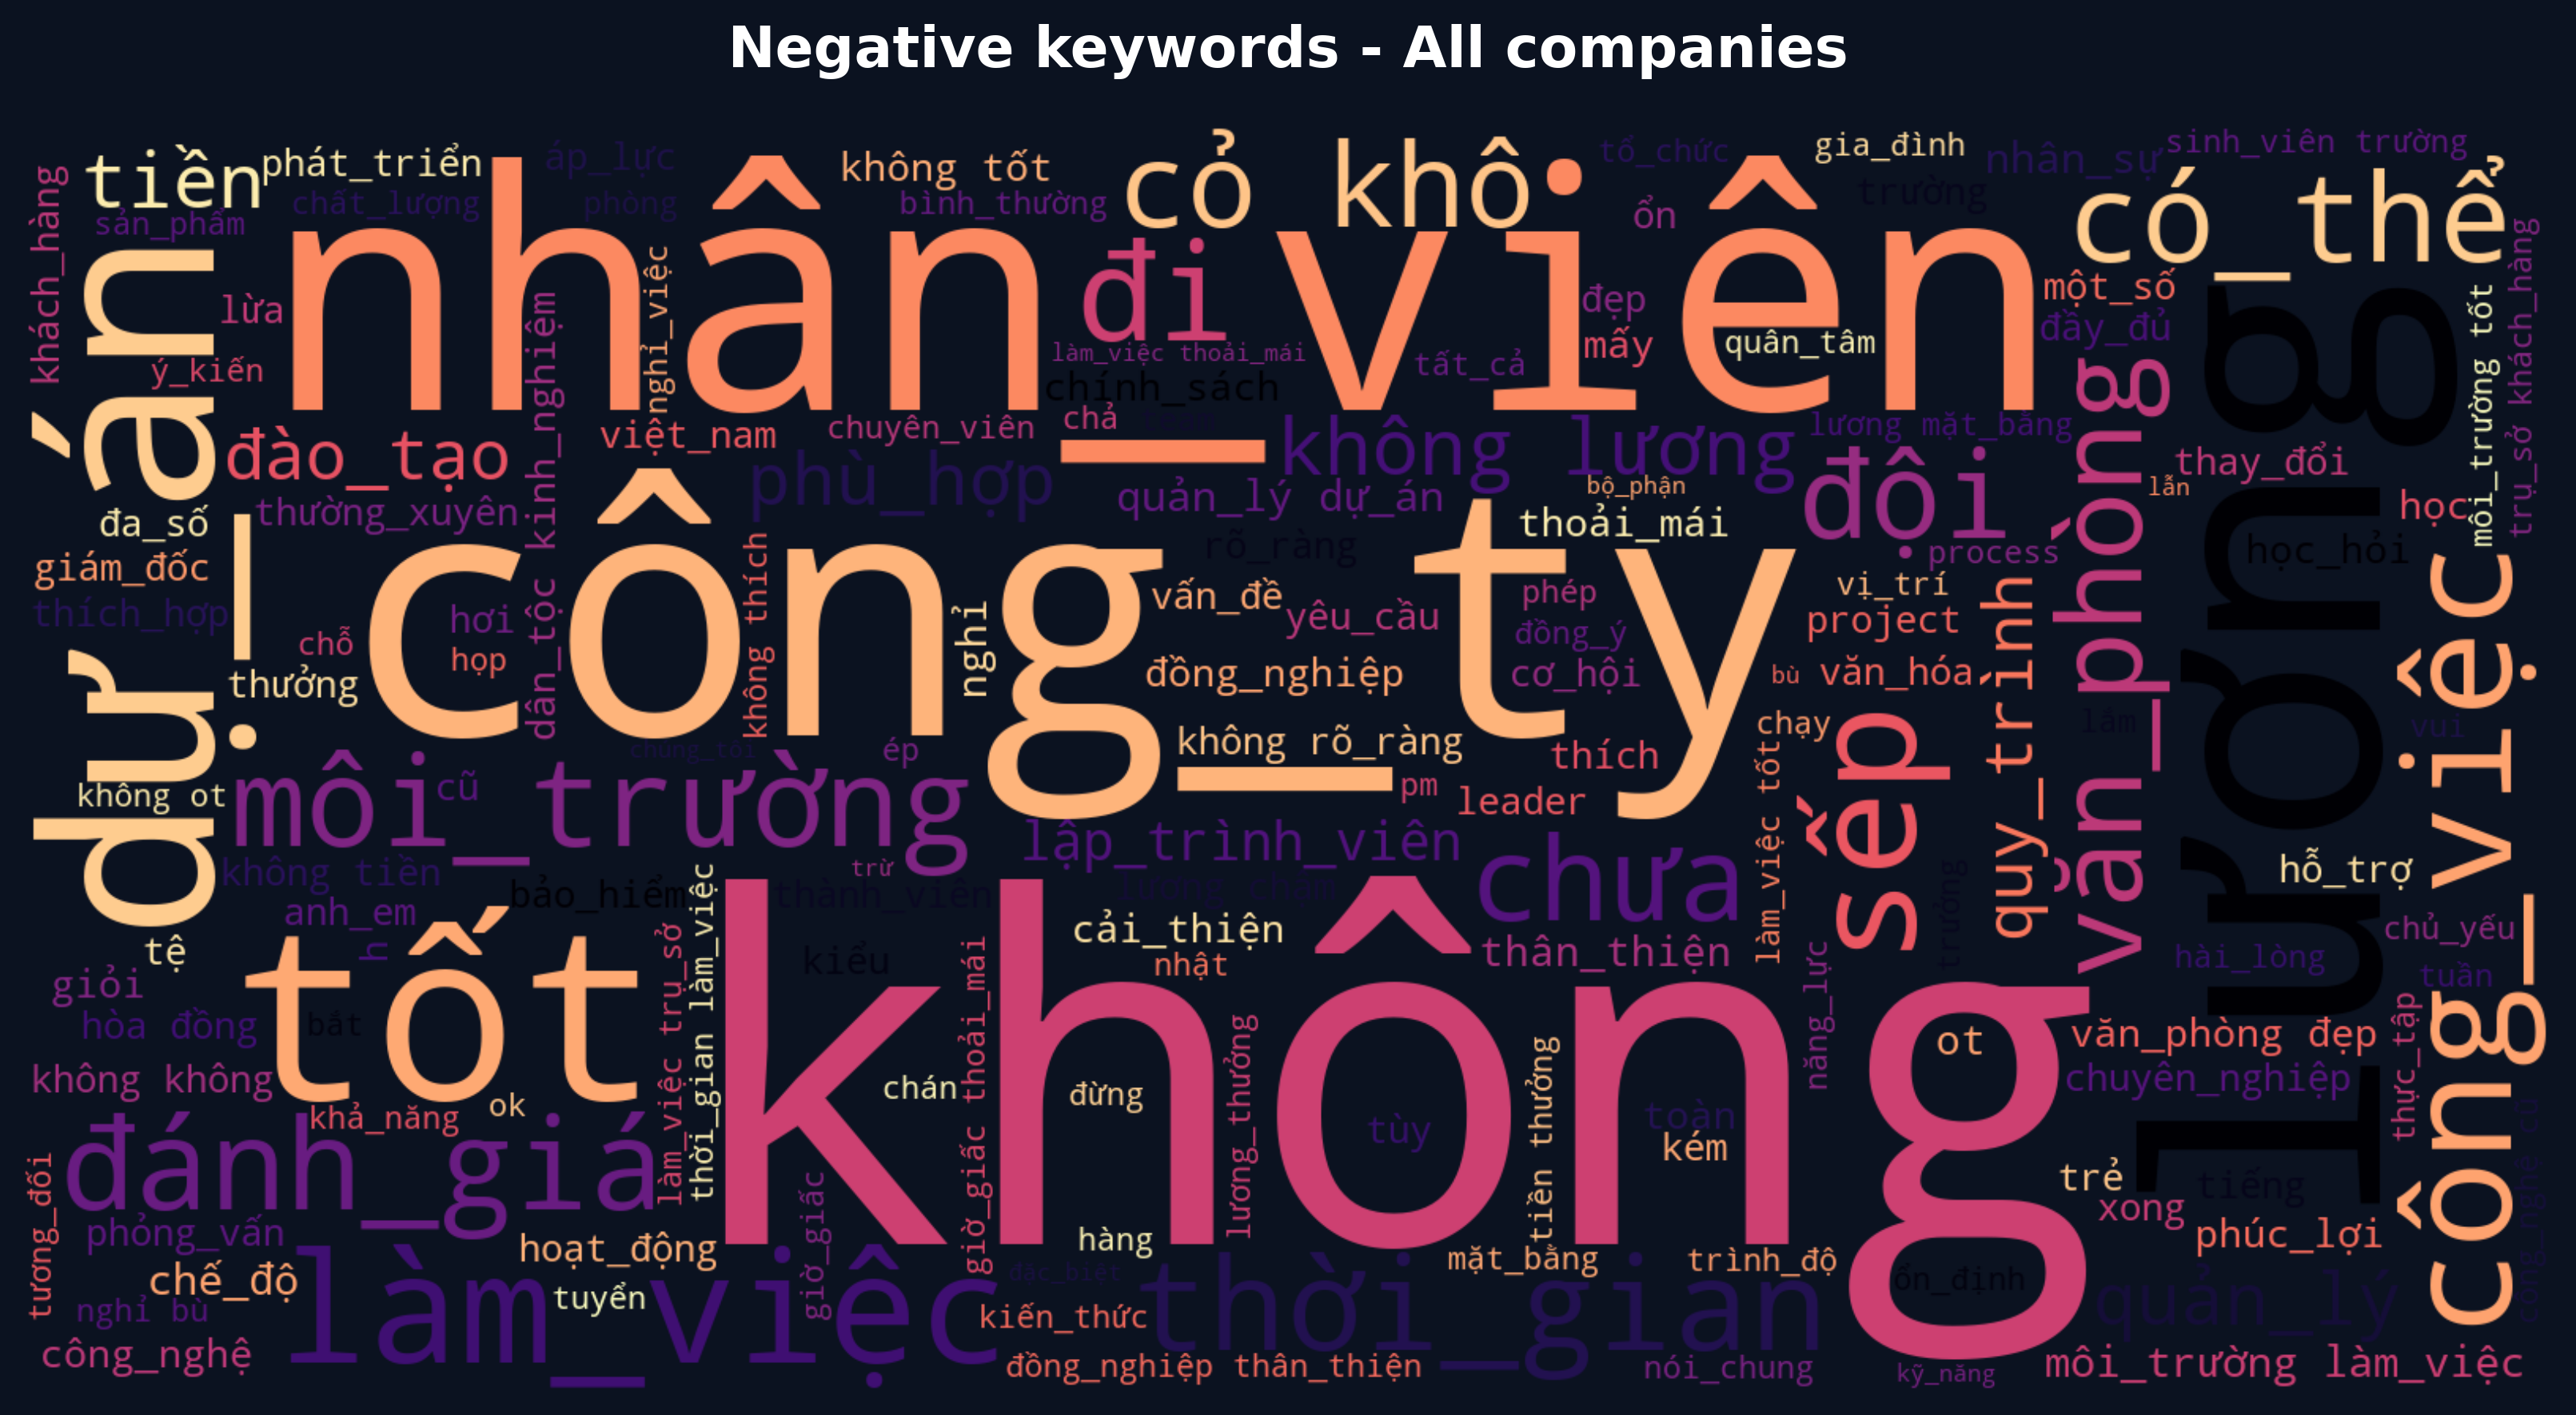

In [4]:
display(Image(filename=str(PROJECT_ROOT / 'reports/figures/wordcloud_positive_all.png'), width=760))
display(Image(filename=str(PROJECT_ROOT / 'reports/figures/wordcloud_negative_all.png'), width=760))

## 4. Từ khóa đặc trưng theo công ty

In [5]:
keywords = pd.read_csv(PROJECT_ROOT / 'reports/company_insights/company_top_keywords.csv')
keywords.groupby(['Company Name', 'sentiment']).head(10)

,Company Name,sentiment,rank,keyword,count
0,FPT Software,Positive,1,tốt,972
1,FPT Software,Positive,2,làm_việc,901
2,FPT Software,Positive,3,không,899
3,FPT Software,Positive,4,môi_trường,863
4,FPT Software,Positive,5,lương,801
...,...,...,...,...,...
185,KMS Technology,Negative,6,ổn,8
186,KMS Technology,Negative,7,công_việc,7
187,KMS Technology,Negative,8,dự_án,7
188,KMS Technology,Negative,9,đánh_giá,6


## Kết luận

WordCloud chỉ phản ánh tần suất từ. Nhãn sentiment được suy ra từ rating nên có thể chứa label noise; không dùng các tỷ lệ này để kết luận quan hệ nhân quả hoặc xếp hạng công ty.